# SIMULACIÓN | LABORATORIO 5- PAUTA


## Boostrap o remuestreo

In [66]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy 
from IPython.display import display
import ipywidgets as widgets
import random
import scipy.stats as stats
import statistics

### Ejercicio 1
Suponga que se ha registrado el tiempo que un conjunto de votantes ha permanecido en la cola antes de votar. Y que a partir de dichos datos, estamos interesados en calcular un intervalo de confianza para la mediana de dicho tiempo.
Para ello utilizaremos remuestreo o bootstrap.
1. Analice el código y evalue el número de muestras de bootstrap para alcanzar convergencia de la varianza estimada de la mediana.
2. Calcule el error cuadrático medio de la mediana.
3. Escoja otro estadístico de la muestra y calcule su incerteza con la técnica de boostrap

In [65]:
from IPython.display import Math
datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
m = statistics.median(datos)
print (m)
b=100
mm = 0
mn =[]
for i in range(b):
    dat = np.random.choice(list(datos),size=n,replace=True)
    mn.append(statistics.median(dat))
    
var = statistics.variance(mn)
print(var)
rango = 1.96*math.sqrt(var)
display(Math('%0.1f \pm %0.1f' % (m, rango )))

              

19.5
38.78977272727273


<IPython.core.display.Math object>

19.5


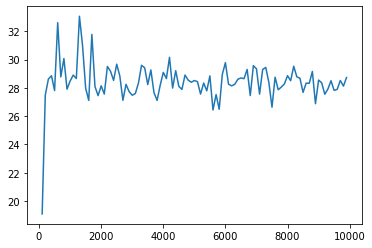

In [17]:
## Ejercicio 1.1
datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
m = statistics.median(datos)
print (m)
var = []
for b in range(100,10000,100):
    mm = 0
    mn =[]
    for i in range(b):
        dat = np.random.choice(list(datos),size=n,replace=True)
        mn.append(statistics.median(dat))
    
    var.append(statistics.variance(mn))
plt.plot(range(100,10000,100),var)


In [19]:
p= statistics.mean(var[21:100])
rango = statistics.stdev(var[21:100])
display(Math('%0.1f \pm %0.1f' % (p, rango )))

<IPython.core.display.Math object>

A partir de muestras bootstrap  de tamaño 2000 se estabiliza la estimación de la varianza en un rango de [27.6,29.2]

In [67]:
#Ejercicio 1.2
from IPython.display import Math
datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
m = statistics.median(datos)
print (m)
b=2000
mm = 0
mse=0
for i in range(b):
    dat = np.random.choice(list(datos),size=n,replace=True)
    mse = mse + (statistics.median(dat)-m)**2

mse= mse/b
print(mse)


19.5
27.5585


44.567039980590806


<IPython.core.display.Math object>

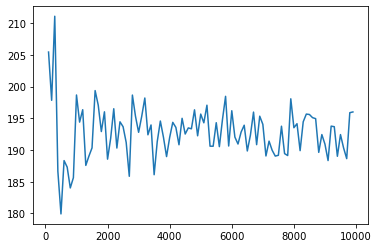

In [53]:
#Ejercicio 1.3
#Calcularemos la incerteza de la desviación estandar de los datos
from IPython.display import Math


datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
des= statistics.stdev(datos)
print (des)
s_mse = []
s_var = []
for b in range(100,10000,100):
    mse=0
    desB= []
    for i in range(b):
        dat = np.random.choice(list(datos),size=n,replace=True)
        desdat = statistics.stdev(dat)
        mse = mse + (desdat-var)**2
        desB.append(desdat)
    
    s_mse.append(mse/(b-1))
    s_var.append(statistics.variance(desB))

#grafico de comportamiento varianza de estimaciones bootstrap de la desviación estándar
plt.plot(range(100,10000,100),s_var)

#intervalo de confianza al  95% para la varianza con bootstrap

varT = s_var[len(s_var)-1]
rango = 1.96* math.sqrt(varT)
display(Math('%0.1f \pm %0.1f' % (des, rango )))

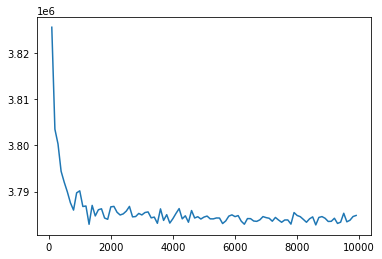

In [54]:
#grfico de comportamiento error cuadrático medio de estimaciones bootstrap de la desviación estándar
plt.plot(range(100,10000,100),s_mse)

En el caso de la desviación estándar, se alcanza estabilización de la incerteza calculada por bootstrap para tamaños de muestra bootstrap mayores a 1500

### Ejercicio 2

Suponga que los datos previamente registrados provienen de una distribución exponencial de tasa $\lambda$. 

1. Calcule el estimador máximo verosímil de $\lambda$
2. Utilice boostrap paramétrico para estimar la incerteza del parámetro estimado en (1). Estime el número de muestras para alcanzar convergencia.
3. Repita el ejercicio con el coeficiente de asimetría de la muestra.



0.030581039755351678


<IPython.core.display.Math object>

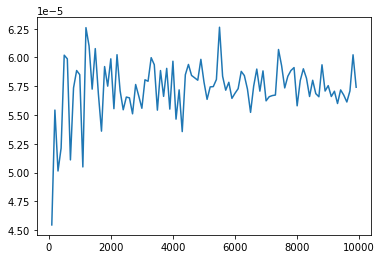

In [62]:
#Ejercicio 2.1 y 2.2
from IPython.display import Math
datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
m = statistics.mean(datos)
# estimador máximo verosímil de lambda
la_mv = 1/m
print(la_mv)
var = []
for b in range(100,10000,100):
    la =[]
    for i in range(b):
        dat = stats.expon.rvs(loc=0,scale=m, size=n) 
        la.append(1/statistics.mean(dat))
    
    var.append(statistics.variance(la))
    
#grafico de comportamiento varianza de estimaciones bootstrap de lambda
plt.plot(range(100,10000,100),var)

#intervalo de confianza al  95% para la varianza con bootstrap
varT = var[len(var)-1] 
rango = 1.96*math.sqrt(varT)
display(Math('%0.2f \pm %0.2f' % (la_mv, rango )))

Varianza bootstrap del EMV de lambda se estabiliza en b=2000 aproximadamente

**Ejercicio 2.3**: estimación de la incerteza del EMV de la varianza: $\bar{X}^2$

1069.2900000000002


<IPython.core.display.Math object>

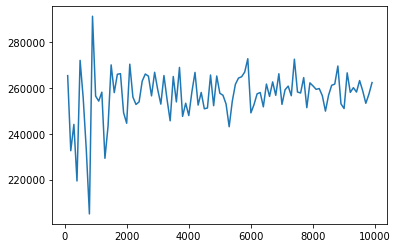

In [64]:
#Ejercicio 2.3: estimación de la incerteza del EMV de la varianza
from IPython.display import Math
datos = [21,10,12,23,180,1,44,125,5,55,4,6,27,22,2,46,15,30,8,18]
n=20
m = statistics.mean(datos)
# estimador máximo verosímil de lambda
var_mv = m**2
print(var_mv)
var = []
for b in range(100,10000,100):
    seq =[]
    for i in range(b):
        dat = stats.expon.rvs(loc=0,scale=m, size=n) 
        seq.append(statistics.mean(dat)**2)
    
    var.append(statistics.variance(seq))
    
#grafico de comportamiento varianza de estimaciones bootstrap de lambda
plt.plot(range(100,10000,100),var)

#intervalo de confianza al  95% para la varianza con bootstrap
varT = var[len(var)-1] 
rango = 1.96*math.sqrt(varT)
display(Math('%0.2f \pm %0.2f' % (var_mv, rango )))

la incerteza de la varianza es alta, del orden de magnitud de la misma.